# RECON precipitation shed

Script to retrieve and plot the reconciled moisture flow of precipitation at the sink (target) originating from
evaporation in upwind locations based on NetCDF moisture flow data (RECON).

This notebook presents an example usage with specific latitude and longitude values of the target (location of precipitation).
You can set a location of precipitation (`lon` and `lat` variables) and get its precipitation shed, i.e., the evaporation flows in upwind cells (sources) contributing to its annual precipitation.

Created by Elena De Petrillo (elena.depetrillo@polito.it) & Luca Monaco (luca.monaco@cimafoundation.org)  
Modified by Romain Thomas (contact@romainthomas.net)

2025

## Imports

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
from pathlib import Path #SZ- added

## Variables

In [2]:
# SZ- adding path management stuff
home = Path.home()
current_dir = Path.cwd()

# Set the path where the dataset is stored
input_file = home / "OneDrive - University of Kansas" / "Research" / "MoistureRecycling" / "RECON" / "RECON_moisture_flows_0.5.nc"
# Set the path where you want to save the plot
output_map_plot_path = "precipitation_shed_map.png"

# Constants for calculation
ymax = 122079329.40990189  # Maximum moisture flow value
ymin = 10**-3  # Minimum moisture flow value

# Modify these coordinates to analyze different points
# # Turin
# lon = 7.7 # from 0 to 360
# lat = 45.1 # from 90 to -90
# # Brazil
# lat = -8
# lon = 311
# SZ- add Garden City
lat = 38
lon = 259

## Data processing

### Load dataset

In [3]:
dataset = xr.open_dataset(input_file)

### Get the precipitation shed

It needs to be converted in cubic meters

In [4]:
precipitation_shed_raw = dataset["moisture_flow"].sel(targetlat=lat, targetlon=lon,method="nearest").values

### Convert to cubic meters

In [5]:
precipitation_shed = np.where(
    precipitation_shed_raw== 0,
    0,
    10**(((precipitation_shed_raw- 1) / 254) * (np.log10(ymax) - np.log10(ymin)) + np.log10(ymin))
)

## Plot results

Plot saved


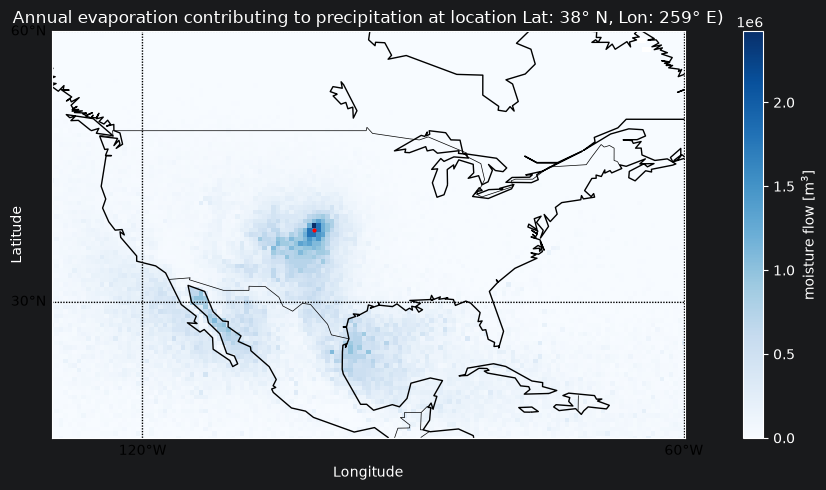

In [6]:
lats = np.arange(90, -90, -0.5)
lons = np.arange(-180, 180, 0.5)

# Shift the data east by 180°
shift_degrees = 180
shift_pixels = int(shift_degrees / (360.0 / precipitation_shed.shape[1]))
shifted_shed = np.roll(precipitation_shed, shift=shift_pixels, axis=1)

plt.figure(figsize=(12, 5))

# Mask zero values in the shifted shed data
masked_shed = np.ma.masked_where(shifted_shed == 0, shifted_shed)
cmap = plt.get_cmap('Blues')
cmap.set_bad(color='white')  # Set masked (zero) values to white

# Create the Basemap, centered at 0°
m = Basemap(
    projection='cyl',
    llcrnrlat=15, urcrnrlat=60,
    llcrnrlon=-130, urcrnrlon=-60,
    resolution='c',
)

# Create lon/lat grids and project them
lon2d, lat2d = np.meshgrid(lons, lats)
x, y = m(lon2d, lat2d)

# Plot the shifted data in map coordinates
cs = m.pcolormesh(x, y, masked_shed, cmap=cmap, shading='auto', vmin=0)

# Add borders, coastlines, grid
m.drawcoastlines()
m.drawcountries()
m.drawparallels(np.arange(-90, 91, 30), labels=[1,0,0,0])
m.drawmeridians(np.arange(0, 361, 60), labels=[0,0,0,1])

# Plot the point in map coordinates
x_pt, y_pt = m((lon + shift_degrees) % 360 - shift_degrees, lat)
m.plot(x_pt, y_pt, 'ro', markersize=3, markeredgewidth=0)

def decimal_to_dms(decimal, is_latitude=False):
    if is_latitude:
        direction = "N" if decimal >= 0 else "S"
    else:
        direction = "E" if decimal >= 0 else "W"
    degrees = abs(decimal)
    return f"{degrees}° {direction}"

plt.colorbar(cs, label="moisture flow [m$^3$]")
plt.title(
    f"Annual evaporation contributing to precipitation at location "
    f"Lat: {decimal_to_dms(lat, True)}, Lon: {decimal_to_dms(lon)})"
)
plt.xlabel("Longitude", labelpad=20)
plt.ylabel("Latitude", labelpad=20)

plt.tight_layout()
plt.savefig(output_map_plot_path, dpi=200, bbox_inches='tight')
print("Plot saved")
plt.show()